In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'
num_months = 12

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :num_months, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, num_months, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2858625586.1356277, 5181567.981463136, 5336661.129950537, 5744266.843404337, 6735091.429620036, 8066134.977786667, 9246550.801534176, 10114750.89622566, 10657521.222459607, 10984366.512217697, 11194839.770347338, 11342621.69280629, 11450906.71192462, 11532892.23554442, 11596274.817626983, 11647801.928267306, 11691459.077631086, 11729228.392932152, 11762992.276470741, 11794139.932014452, 11822151.037138443, 11846876.19516458, 11869316.848503036, 11890715.718279768, 11911940.099221146, 11932241.48412284, 11949974.326284446, 11964614.714879189, 11976755.284234717, 11987544.248298567, 11997430.93033265, 12006445.983460369, 12014763.110667717, 12022520.531848699, 12029812.976644937, 12036649.573004907, 12043033.958054015, 12049009.469109742, 12054603.592331653, 12059835.757355556, 12064727.80564017, 12069297.237329423, 12073563.055297015, 12077550.535845941, 12081277.393920125, 12084723.17939542

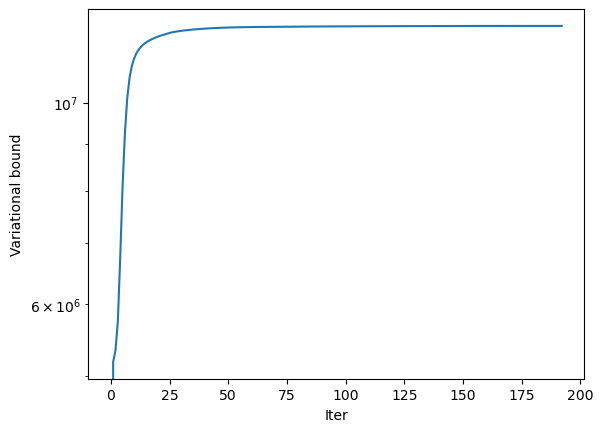

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-6
verbose = False

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with last mode completely masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2701134030.666777, 5302991.770559686, 5405259.5590075925, 5758598.177090877, 6684834.080537729, 7925549.834199621, 9036104.690805214, 9901840.720792849, 10486363.86919505, 10861046.508309312, 11110031.618428407, 11279909.621274572, 11400324.248174088, 11493362.353057846, 11571121.632906726, 11637103.834478604, 11693106.553903751, 11740955.10710109, 11782509.903475204, 11820115.983475339, 11856146.65162938, 11887963.26347419, 11911531.630823523, 11930791.402982818, 11947659.178582715, 11962879.674511736, 11976977.31336765, 11990434.533009175, 12003880.755451122, 12018315.610835109, 12034653.534664722, 12051492.49339541, 12065867.434040293, 12077407.790823136, 12086806.3759496, 12094702.663461138, 12101514.68771662, 12107527.669193337, 12112938.013943493, 12117883.625611778, 12122442.22878385, 12126645.64103023, 12130509.34830058, 12134045.568368446, 12137271.553653369, 12140207.361001365, 12

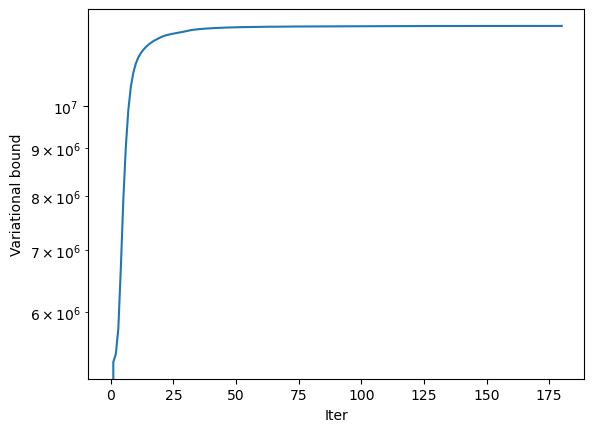

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with the 1st and 3rd indices masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2771686513.6302104, 5712226.836958245, 6152240.3665633695, 6611415.608565306, 7556979.188715996, 8709859.712397706, 9964910.296867125, 10908513.390941774, 11500707.601054199, 11902698.503255008, 12178956.859292813, 12369921.05842591, 12509590.936815443, 12614414.66200382, 12695163.204826102, 12760173.47194153, 12815079.055404989, 12862839.064415662, 12904303.620813932, 12939720.8252339, 12970436.07450358, 12998269.932424787, 13024942.551159568, 13051856.19410856, 13078092.996771317, 13099932.833331566, 13116972.875445051, 13131004.738562264, 13143474.959179696, 13155148.96137503, 13166175.132257856, 13176290.75584247, 13185606.480119715, 13194348.85768543, 13202366.481245432, 13209617.26870475, 13216342.521749135, 13222758.982255021, 13228961.59310195, 13235088.377085665, 13241369.914973667, 13248095.824484566, 13255689.390061172, 13264511.988068994, 13274551.05633012, 13284816.314488076, 1

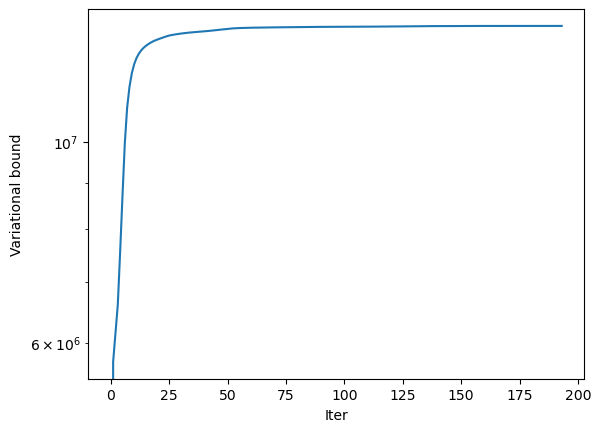

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2954168167.687335, 5944729.366823903, 6070428.925287057, 6606319.952424211, 7720571.870467945, 8997094.826159911, 10206670.24687971, 11100652.368982198, 11683919.515799632, 12067786.245713234, 12328569.450360784, 12508903.121313414, 12638411.022397177, 12736523.052689658, 12813948.221647283, 12877275.136616655, 12931079.018765371, 12978247.597193964, 13020520.035397312, 13058863.275373947, 13093666.947151735, 13124630.09475004, 13151023.303584645, 13173170.894962685, 13192004.045122826, 13208217.867742056, 13222386.834000725, 13234980.25651579, 13246327.78813876, 13256634.924474671, 13266049.042304914, 13274687.307719588, 13282647.930363838, 13290034.39793022, 13296915.895764172, 13303366.178349199, 13309446.524470525, 13315209.71172875, 13320696.159082217, 13325937.168394921, 13330938.867699798, 13335696.920083934, 13340204.673443448, 13344448.44191125, 13348420.126116283, 13352116.9886747

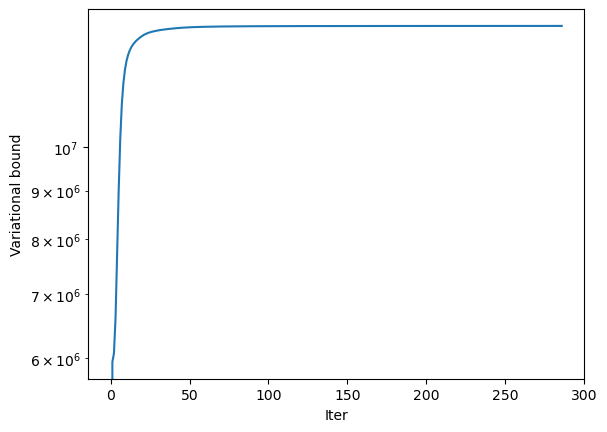

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# No mask

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2912418882.6598077, -8026865.490582786, -8025246.979435525, -8024214.1283604195, -8020864.426593402, -8015503.490909545, -8008331.468347959, -8001210.132358161, -7996295.469188532, -7993273.098477179, -7991196.101817019, -7989595.057865155, -7988392.707079315, -7987490.489825644, -7986771.658027969, -7986165.569513544, -7985635.688818037, -7985162.236505174, -7984738.279281463, -7984359.346377576, -7984021.973897982, -7983723.710649227, -7983452.001247953, -7983198.381272116, -7982968.3813160425, -7982761.572928359, -7982572.812401824, -7982401.875960425, -7982246.736934646, -7982105.828368494, -7981973.2213053815, -7981849.309556506, -7981728.380421652, -7981613.652795937, -7981507.632625984, -7981405.414028867, -7981310.976305211, -7981222.259288219, -7981139.491188851, -7981062.073949303, -7980988.4985369835, -7980919.388985931, -7980855.64684584, -7980794.083950752, -7980731.5558314845,

/home/luiyusen/projects/bptf_new/own_implementation.py:283: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


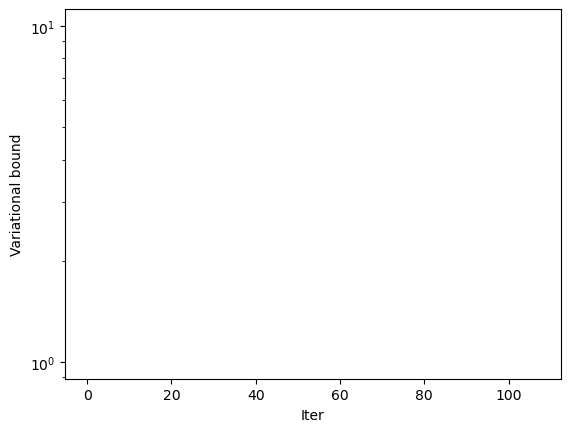

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [9]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)

In [10]:
with torch.no_grad():
    # torch.cuda.synchronize()
    b1 = BPTF_model._elbo(data, mask)
    torch.cuda.synchronize()
    b2 = BPTF_model._elbo(data, mask)
print((b2 - b1) * 1e8)               # absolute change in “ULPs”

tensor(0., device='cuda:0')
